In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Câu 1

Đọc file dữ liệu
rock_physical.csv vào DataFrame.

In [34]:
df = pd.read_csv('rock_physical.csv')

 In ra 5 dòng đầu tiên của dữ liệu.

In [35]:
df.head(5)

,Ord No (sample number),Poros [% vol],k [W/m/K] (unsaturated),k [W/m/K] (saturated),Vp [m/s] (unsaturated),Vp [m/s] (saturated),Rock,Country,Area (region),Area (location),Stratigraphy (Chronostratigraphy)
0,1,NaN,2.57,NaN,2850,NaN,Fine sandstone,Germany,Mainz Basin,Alsenz,Permo-Carboniferous (Rotliegend)
1,2,3.10,2.58,NaN,4640,NaN,Fine sandstone,Germany,Mainz Basin,Alsenz,Permo-Carboniferous (Rotliegend)
2,3,3.94,3.09,NaN,5040,NaN,Fine sandstone,Germany,Mainz Basin,Alsenz,Permo-Carboniferous (Rotliegend)
3,4,6.05,2.28,NaN,4560,NaN,Fine sandstone,Germany,Mainz Basin,Altenglan,Permo-Carboniferous (Rotliegend)
4,5,6.33,2.34,NaN,4550,NaN,Fine sandstone,Germany,Mainz Basin,Altenglan,Permo-Carboniferous (Rotliegend)


In ra kiểu dữ liệu và thông tin chi tiết của các cột.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Ord No (sample number)             1430 non-null   int64  
 1   Poros [% vol]                      663 non-null    float64
 2   k [W/m/K] (unsaturated)            1430 non-null   float64
 3   k [W/m/K] (saturated)              108 non-null    float64
 4   Vp [m/s] (unsaturated)             1430 non-null   int64  
 5   Vp [m/s] (saturated)               108 non-null    float64
 6   Rock                               1430 non-null   object 
 7   Country                            1327 non-null   object 
 8   Area (region)                      1279 non-null   object 
 9   Area (location)                    957 non-null    object 
 10  Stratigraphy (Chronostratigraphy)  1065 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 123.0+ 

Có bao nhiêu loại đá (Rock) khác nhau trong tập dữ liệu?

In [37]:
num_unique_rocks = df['Rock'].nunique()
print(f"Số loại đá (Rock) khác nhau trong tập dữ liệu là: {num_unique_rocks}")

Số loại đá (Rock) khác nhau trong tập dữ liệu là: 18


Liệt kê tất cả tên loại đá trong cột Rock.

In [38]:
unique_rocks = df['Rock'].unique()
print("Các loại đá (Rock) trong tập dữ liệu là:")
for rock in unique_rocks:
    print(f"- {rock}")

Các loại đá (Rock) trong tập dữ liệu là:
- Fine sandstone
- Medium sandstone
- Coarse sandstone
- Arkose
- Graywacke
- Limestone
- Marl
- Dolomite
- Marble
- Coquina
- Gabbro
- Gabbrodiorite
- Diorite
- Granodiorite
- Granite
- Basalt
- Andesite
- Rhyolite


Có bao nhiêu vùng địa lý (Country) được ghi nhận trong dataset?

In [39]:
num_unique_countries = df['Country'].nunique()
print(f"Số vùng địa lý (Country) trong tập dữ liệu là: {num_unique_countries}")

Số vùng địa lý (Country) trong tập dữ liệu là: 7


 In thống kê cơ bản
describe() cho dữ liệu này.

In [40]:
display(df.describe())

,Ord No (sample number),Poros [% vol],k [W/m/K] (unsaturated),k [W/m/K] (saturated),Vp [m/s] (unsaturated),Vp [m/s] (saturated)
count,1430.000000,663.000000,1430.000000,108.000000,1430.000000,108.000000
mean,715.500000,10.323439,2.464615,3.744815,4057.713287,4115.555556
std,412.949755,7.714492,0.490548,0.318071,1359.213080,848.174878
min,1.000000,0.010000,0.560000,3.090000,1140.000000,2820.000000
25%,358.250000,2.485000,2.210000,3.557500,2840.000000,3465.000000
50%,715.500000,12.070000,2.530000,3.715000,3915.000000,4000.000000
75%,1072.750000,16.515000,2.770000,3.857500,5180.000000,4440.000000
max,1430.000000,34.000000,4.640000,4.590000,7620.000000,6310.000000


Xác định 3 loại đá có độ rỗng trung bình
Poros [% vol] thấp nhất.

In [41]:
avg_porosity_by_rock = df.groupby('Rock')['Poros [% vol]'].mean()
lowest_porosity_rocks = avg_porosity_by_rock.sort_values(ascending=True, na_position='last').head(3)
print("3 loại đá có độ rỗng trung bình thấp nhất:")
display(lowest_porosity_rocks)

3 loại đá có độ rỗng trung bình thấp nhất:


,Poros [% vol]
Rock,
Diorite,1.023000
Marl,1.272000
Granodiorite,1.561739


Tính giá trị trung bình của
Poros [% vol] toàn dataset. Từ đó, lọc ra các mẫu có độ rỗng cao hơn giá trị trung bình này.

In [42]:
overall_avg_porosity = df['Poros [% vol]'].mean()
print(f"Giá trị trung bình của Poros [% vol] toàn dataset là: {overall_avg_porosity:.2f}")

porosity_above_average_samples = df[df['Poros [% vol]'] > overall_avg_porosity]
print("Các mẫu có độ rỗng cao hơn giá trị trung bình:")
display(porosity_above_average_samples)

Giá trị trung bình của Poros [% vol] toàn dataset là: 10.32
Các mẫu có độ rỗng cao hơn giá trị trung bình:


,Ord No (sample number),Poros [% vol],k [W/m/K] (unsaturated),k [W/m/K] (saturated),Vp [m/s] (unsaturated),Vp [m/s] (saturated),Rock,Country,Area (region),Area (location),Stratigraphy (Chronostratigraphy)
10,11,12.07,2.58,NaN,3250,NaN,Fine sandstone,Germany,Mainz Basin,Erzweiler,Permo-Carboniferous (Rotliegend)
11,12,12.32,3.37,NaN,3910,NaN,Fine sandstone,Germany,Mainz Basin,Essweiler,Permo-Carboniferous (Rotliegend)
12,13,12.59,3.59,NaN,3930,NaN,Fine sandstone,Germany,Mainz Basin,Essweiler,Permo-Carboniferous (Rotliegend)
13,14,17.16,2.20,3.59,2010,2930.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
14,15,18.13,2.26,3.65,2840,3280.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
...,...,...,...,...,...,...,...,...,...,...,...
1425,1426,19.49,1.15,NaN,2540,NaN,Rhyolite,New Zealand,Central Volcanic Zone,Rotorua,NaN
1426,1427,20.07,1.17,NaN,2380,NaN,Rhyolite,New Zealand,Central Volcanic Zone,Rotorua,NaN
1427,1428,20.78,1.17,NaN,1960,NaN,Rhyolite,New Zealand,Central Volcanic Zone,Rotorua,NaN
1428,1429,20.71,1.20,NaN,2660,NaN,Rhyolite,New Zealand,Central Volcanic Zone,Rotorua,NaN


Trong nhóm có độ rỗng cao hơn giá trị trung bình ở phía trên, liệt kê 5 mẫu có
Vp [m/s] (unsaturated) lớn nhất.

In [43]:
top_5_vp_unsaturated = porosity_above_average_samples.sort_values(by='Vp [m/s] (unsaturated)', ascending=False).head(5)
print("5 mẫu có Vp [m/s] (unsaturated) lớn nhất trong nhóm độ rỗng cao hơn trung bình:")
display(top_5_vp_unsaturated)

5 mẫu có Vp [m/s] (unsaturated) lớn nhất trong nhóm độ rỗng cao hơn trung bình:


,Ord No (sample number),Poros [% vol],k [W/m/K] (unsaturated),k [W/m/K] (saturated),Vp [m/s] (unsaturated),Vp [m/s] (saturated),Rock,Country,Area (region),Area (location),Stratigraphy (Chronostratigraphy)
304,305,15.27,3.18,NaN,4570,NaN,Medium sandstone,Germany,Mainz Basin,NaN,Permo-Carboniferous (Rotliegend)
1337,1338,11.02,1.17,NaN,4550,NaN,Andesite,New Zealand,Central Volcanic Zone,Tokaanu,NaN
1284,1285,14.70,1.18,NaN,4070,NaN,Basalt,Island,NaN,NaN,Quaternary
292,293,14.80,2.98,NaN,4010,NaN,Medium sandstone,Germany,Mainz Basin,NaN,Permo-Carboniferous (Rotliegend)
407,408,12.51,2.70,NaN,3980,NaN,Medium sandstone,Germany,Spessart,Sterbfritz,Triassic (Buntsandstein)


 Trong nhóm có độ rỗng cao hơn giá trị trung bình ở phía trên, loại đá nào có giá trị trung bình
Vp [m/s] (unsaturated) cao
 nhất?

In [44]:
avg_vp_unsaturated_by_rock = porosity_above_average_samples.groupby('Rock')['Vp [m/s] (unsaturated)'].mean()
highest_vp_rock = avg_vp_unsaturated_by_rock.idxmax()
highest_vp_value = avg_vp_unsaturated_by_rock.max()
print(f"Trong nhóm có độ rỗng cao hơn giá trị trung bình, loại đá có Vp [m/s] (unsaturated) trung bình cao nhất là: {highest_vp_rock}")
print(f"Với giá trị Vp [m/s] (unsaturated) trung bình là: {highest_vp_value:.2f}")

Trong nhóm có độ rỗng cao hơn giá trị trung bình, loại đá có Vp [m/s] (unsaturated) trung bình cao nhất là: Andesite
Với giá trị Vp [m/s] (unsaturated) trung bình là: 3508.00


Lọc ra những mẫu có
Poros [% vol] > 15 và
k [W/m/K] (unsaturated) > 2.0.

In [45]:
filtered_samples = df[(df['Poros [% vol]'] > 15) & (df['k [W/m/K] (unsaturated)'] > 2.0)]
print("Các mẫu có Poros [% vol] > 15 và k [W/m/K] (unsaturated) > 2.0:")
display(filtered_samples)

Các mẫu có Poros [% vol] > 15 và k [W/m/K] (unsaturated) > 2.0:


,Ord No (sample number),Poros [% vol],k [W/m/K] (unsaturated),k [W/m/K] (saturated),Vp [m/s] (unsaturated),Vp [m/s] (saturated),Rock,Country,Area (region),Area (location),Stratigraphy (Chronostratigraphy)
13,14,17.16,2.20,3.59,2010,2930.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
14,15,18.13,2.26,3.65,2840,3280.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
15,16,17.99,2.27,NaN,2610,NaN,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
16,17,18.04,2.28,3.56,1810,3130.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
17,18,17.58,2.37,3.77,2790,3160.0,Fine sandstone,Germany,Mainz Basin,Hochstätten,Permo-Carboniferous (Rotliegend)
...,...,...,...,...,...,...,...,...,...,...,...
577,578,21.13,2.73,4.59,2680,4400.0,Arkose,Germany,Mainz Basin,Langenthal,Permo-Carboniferous (Rotliegend)
578,579,19.86,2.74,4.51,2790,4070.0,Arkose,Germany,Mainz Basin,Langenthal,Permo-Carboniferous (Rotliegend)
579,580,15.88,2.75,3.72,2780,4640.0,Arkose,Germany,Mainz Basin,Langenthal,Permo-Carboniferous (Rotliegend)
580,581,16.32,2.75,3.63,3060,4310.0,Arkose,Germany,Mainz Basin,Langenthal,Permo-Carboniferous (Rotliegend)


Tính trung bình
 Vp [m/s] (unsaturated) và
k [W/m/K] (unsaturated) cho các mẫu thỏa điều kiện trên.

In [46]:
avg_vp_unsaturated_filtered = filtered_samples['Vp [m/s] (unsaturated)'].mean()
avg_k_unsaturated_filtered = filtered_samples['k [W/m/K] (unsaturated)'].mean()
print(f"Giá trị trung bình của Vp [m/s] (unsaturated) cho các mẫu đã lọc là: {avg_vp_unsaturated_filtered:.2f}")
print(f"Giá trị trung bình của k [W/m/K] (unsaturated) cho các mẫu đã lọc là: {avg_k_unsaturated_filtered:.2f}")

Giá trị trung bình của Vp [m/s] (unsaturated) cho các mẫu đã lọc là: 2687.63
Giá trị trung bình của k [W/m/K] (unsaturated) cho các mẫu đã lọc là: 2.39


Với từng loại đá
Rock , tính giá trị trung bình độ rỗng
Poros [% vol].

In [47]:
avg_porosity_by_rock = df.groupby('Rock')['Poros [% vol]'].mean()
print("Giá trị trung bình độ rỗng theo từng loại đá:")
display(avg_porosity_by_rock)

Giá trị trung bình độ rỗng theo từng loại đá:


,Poros [% vol]
Rock,
Andesite,4.972609
Arkose,19.144828
Basalt,11.842667
Coarse sandstone,17.669020
Coquina,NaN
Diorite,1.023000
Dolomite,2.396818
Fine sandstone,11.067846
Gabbro,2.613333


Với từng vùng
Country , đếm xem có bao nhiêu mẫu đá
Rock được ghi nhận.

In [48]:
rock_count_by_country = df.groupby('Country')['Rock'].count()
print("Số lượng mẫu đá được ghi nhận cho từng quốc gia:")
display(rock_count_by_country)

Số lượng mẫu đá được ghi nhận cho từng quốc gia:


,Rock
Country,
China,93
Germany,1076
Island,31
Italy,14
Jordan,12
New Zealand,82
South Africa,19


Tính giá trị trung bình và độ lệch chuẩn của
Vp [m/s] (unsaturated) cho từng loại đá
Rock.

In [49]:
avg_vp_unsaturated_by_rock = df.groupby('Rock')['Vp [m/s] (unsaturated)'].mean()
std_vp_unsaturated_by_rock = df.groupby('Rock')['Vp [m/s] (unsaturated)'].apply(lambda x: np.std(x.dropna(), ddof=1))
print("Giá trị trung bình của Vp [m/s] (unsaturated) theo từng loại đá:")
display(avg_vp_unsaturated_by_rock)
print("\nĐộ lệch chuẩn của Vp [m/s] (unsaturated) theo từng loại đá:")
display(std_vp_unsaturated_by_rock)

Giá trị trung bình của Vp [m/s] (unsaturated) theo từng loại đá:


,Vp [m/s] (unsaturated)
Rock,
Andesite,4133.695652
Arkose,2810.000000
Basalt,4726.666667
Coarse sandstone,2640.263158
Coquina,3851.666667
Diorite,5730.416667
Dolomite,5139.166667
Fine sandstone,3307.032967
Gabbro,6252.261905



Độ lệch chuẩn của Vp [m/s] (unsaturated) theo từng loại đá:


,Vp [m/s] (unsaturated)
Rock,
Andesite,810.109344
Arkose,327.512268
Basalt,1163.197287
Coarse sandstone,554.044598
Coquina,342.315851
Diorite,861.371400
Dolomite,1147.170116
Fine sandstone,728.355064
Gabbro,479.101446


Tính giá trị trung bình của k (unsaturated) và Vp (unsaturated) cho từng loại đá. → Sắp xếp kết quả theo Vp (unsaturated) giảm
 dần.

In [50]:
avg_k_vp_unsaturated_by_rock = df.groupby('Rock')[['k [W/m/K] (unsaturated)', 'Vp [m/s] (unsaturated)']].mean()
sorted_avg_k_vp = avg_k_vp_unsaturated_by_rock.sort_values(by='Vp [m/s] (unsaturated)', ascending=False)
print("Giá trị trung bình của k (unsaturated) và Vp (unsaturated) theo từng loại đá, sắp xếp theo Vp giảm dần:")
display(sorted_avg_k_vp)

Giá trị trung bình của k (unsaturated) và Vp (unsaturated) theo từng loại đá, sắp xếp theo Vp giảm dần:


,k [W/m/K] (unsaturated),Vp [m/s] (unsaturated)
Rock,,
Gabbro,2.417262,6252.261905
Gabbrodiorite,2.552353,5845.294118
Diorite,2.478333,5730.416667
Granite,2.791373,5143.856209
Dolomite,2.677083,5139.166667
Graywacke,2.860000,5044.166667
Limestone,2.450741,5028.888889
Marl,2.587907,5008.372093
Basalt,1.699067,4726.666667


Nhóm dữ liệu theo cả hai cột Rock và Country, rồi tính trung bình và khoảng tứ phân vị của:
-  Poros [% vol]
-  Vp [m/s] (unsaturated)
-  k [W/m/K] (unsaturated)

In [51]:
grouped_stats = df.groupby(['Rock', 'Country'])[['Poros [% vol]', 'Vp [m/s] (unsaturated)', 'k [W/m/K] (unsaturated)']].describe()
print("Giá trị trung bình và khoảng tứ phân vị theo Rock và Country:")
display(grouped_stats)

Giá trị trung bình và khoảng tứ phân vị theo Rock và Country:


Poros [% vol]                               \
                                      count       mean        std    min   
Rock             Country                                                   
Andesite         New Zealand           46.0   4.972609   5.325499   0.49   
Arkose           Germany               29.0  19.144828   2.654714  13.64   
Basalt           Germany                5.0   6.148000   5.377111   1.18   
                 Island                10.0  14.690000  10.620049   0.70   
                 Jordan                 0.0        NaN        NaN    NaN   
Coarse sandstone Germany               51.0  17.669020   3.745253   8.31   
Diorite          Germany               20.0   1.023000   0.626990   0.28   
Dolomite         Germany               22.0   2.396818   1.668902   0.28   
Fine sandstone   Germany               65.0  11.067846   5.374189   2.44   
Gabbro           Germany                3.0   2.613333   2.307647   0.06   
                 South Africa           0.0        NaN        NaN    NaN   
Gabbrodiorite    Germany                0.0        NaN        NaN    NaN   
Granite          China                  0.0        NaN        NaN    NaN   
                 Germany                2.0   3.745000   0.657609   3.28   
Granodiorite     Germany               46.0   1.561739   2.200500   0.03   
Graywacke        Germany               14.0   2.770000   0.955929   1.62   
                 New Zealand           15.0   0.699333   0.910490   0.01   
Limestone        Germany               45.0   2.972667   1.363197   0.12   
Marble           Italy                  0.0        NaN        NaN    NaN   
Marl             Germany               40.0   1.272000   0.714947   0.13   
Medium sandstone Germany              234.0  14.948419   4.412448   2.95   
Rhyolite         Germany                0.0        NaN        NaN    NaN   
                 New Zealand           16.0  23.132500   3.759900  17.82   

                                                                \
                                   25%     50%      75%    max   
Rock             Country                                         
Andesite         New Zealand    1.4450   2.220   6.3400  19.56   
Arkose           Germany       16.7300  19.860  21.5400  22.07   
Basalt           Germany        2.1000   3.680  10.7600  13.02   
                 Island         8.4000  14.400  21.0250  34.00   
                 Jordan            NaN     NaN      NaN    NaN   
Coarse sandstone Germany       14.5100  19.310  20.3500  23.10   
Diorite          Germany        0.5100   0.990   1.2225   2.60   
Dolomite         Germany        1.0750   2.160   3.4950   6.51   
Fine sandstone   Germany        6.3300  12.170  15.2200  23.51   
Gabbro           Germany        1.6450   3.230   3.8900   4.55   
                 South Africa      NaN     NaN      NaN    NaN   
Gabbrodiorite    Germany           NaN     NaN      NaN    NaN   
Granite          China             NaN     NaN      NaN    NaN   
                 Germany        3.5125   3.745   3.9775   4.21   
Granodiorite     Germany        0.3900   0.585   1.8375   9.44   
Graywacke        Germany        2.3625   2.740   2.9800   5.64   
                 New Zealand    0.1500   0.350   0.8000   2.94   
Limestone        Germany        2.2500   2.700   3.7600   6.02   
Marble           Italy             NaN     NaN      NaN    NaN   
Marl             Germany        0.6800   1.250   1.6900   2.75   
Medium sandstone Germany       13.3550  15.170  17.5450  22.17   
Rhyolite         Germany           NaN     NaN      NaN    NaN   
                 New Zealand   20.5500  23.025  24.4850  31.88   

                              Vp [m/s] (unsaturated)               ...  \
                                               count         mean  ...   
Rock             Country                                           ...   
Andesite         New Zealand                    46.0  4133.695652  ...   
Arkose           Germany                

Vẽ biểu đồ histogram cho biến
k [W/m/K] (unsaturated) và nhận xét.

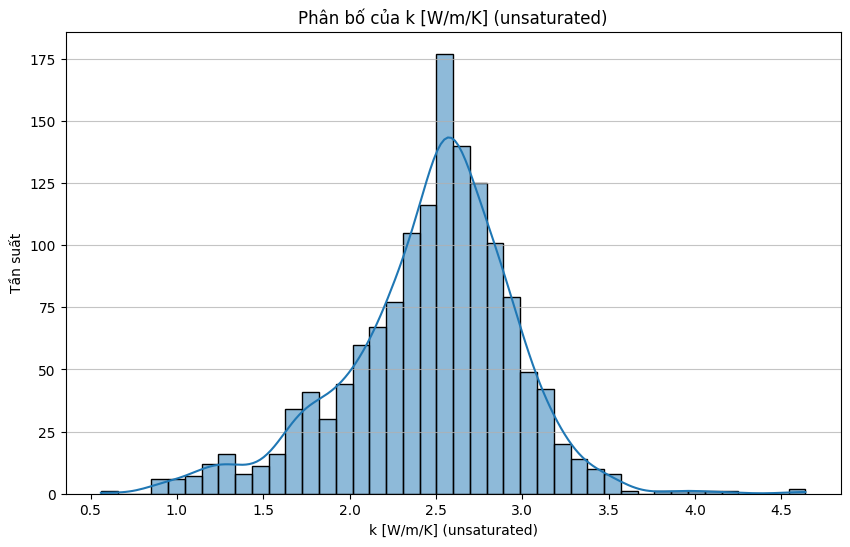

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['k [W/m/K] (unsaturated)'].dropna(), kde=True)
plt.title('Phân bố của k [W/m/K] (unsaturated)')
plt.xlabel('k [W/m/K] (unsaturated)')
plt.ylabel('Tần suất')
plt.grid(axis='y', alpha=0.75)
plt.show()

Nhận xét: Biểu đồ cho thấy dữ liệu có dạng lệch phải rõ rệt. Phần lớn các mẫu đá có độ dẫn nhiệt tập trung ở mức thấp, chủ yếu trong khoảng 2.0 đến 3.0 W/m/K, và có một "đuôi" dài gồm các mẫu có độ dẫn nhiệt cao hơn hẳn.

Vẽ biểu đồ boxplot và biểu đồ hàm phân phối tích lũy thực nghiệm (ECDF) cho biến
Vp [m/s] (unsaturated) và nhận xét.

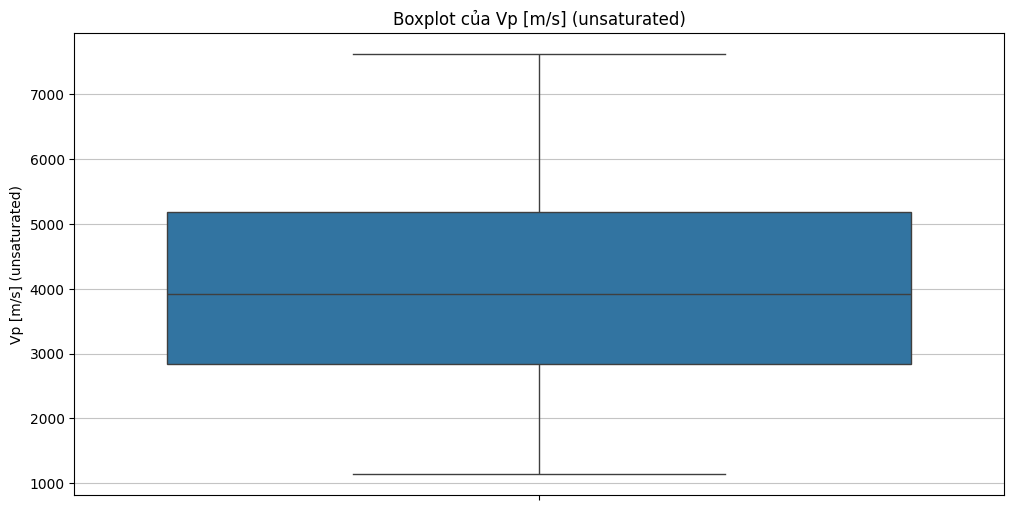

In [53]:
plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Vp [m/s] (unsaturated)'].dropna())
plt.title('Boxplot của Vp [m/s] (unsaturated)')
plt.ylabel('Vp [m/s] (unsaturated)')
plt.grid(axis='y', alpha=0.75)
plt.show()

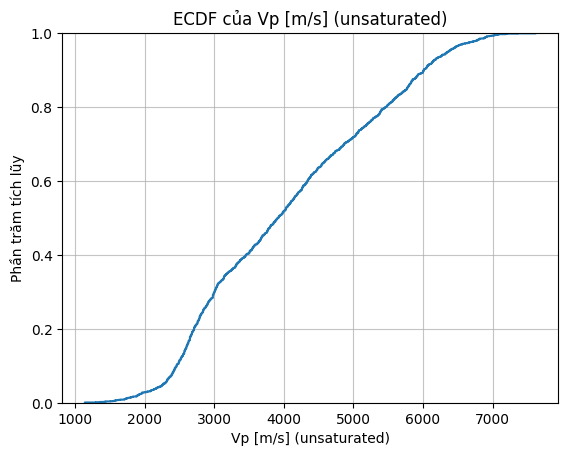

In [54]:
sns.ecdfplot(x=df['Vp [m/s] (unsaturated)'].dropna())
plt.title('ECDF của Vp [m/s] (unsaturated)')
plt.xlabel('Vp [m/s] (unsaturated)')
plt.ylabel('Phần trăm tích lũy')
plt.grid(alpha=0.75)
plt.show()

Nhận xét: Cả 2 biểu đồ đều cung cấp thông tin bổ trợ cho nhau.
- Boxplot: Cho thấy 50% dữ liệu trung tâm (khoảng tứ phân vị) nằm trong khoảng từ 2800 đến 5200 m/s, với giá trị trung vị (median) xấp xỉ 3900 m/s. Điểm đáng chú ý nhất là sự xuất hiện của rất nhiều giá trị ngoại lai (outliers) ở phía trên (vận tốc cao).
- ECDF: Biểu đồ xác nhận điều này. Đường cong dốc nhất ở khoảng trung tâm (nơi dữ liệu tập trung) và thoải dần ở phía bên phải, cho thấy sự tồn tại của các giá trị cao nhưng thưa thớt, tương ứng với các outliers trên boxplot.

# Câu 2

 Đọc dữ liệu và in ra 10 dòng đầu tiên.

In [55]:
data = pd.read_csv('CaCO3_Stratigraphy_ODP1090.csv')
data.head(10)

,Unnamed: 0,Depth_m,Age_ka,Sample_label,Depth_mcd,CaCO3,Depth_group
0,0,20.43,829,"177-1090E-3H-2,73-74",27.14,86.189,Shallow
1,1,20.47,830,"177-1090E-3H-2,77-78",27.18,82.309,Shallow
2,2,20.51,830,"177-1090E-3H-2,81-82",27.22,81.270,Shallow
3,3,20.55,831,"177-1090E-3H-2,85-86",27.26,74.991,Shallow
4,4,20.59,832,"177-1090E-3H-2,89-90",27.30,72.752,Shallow
5,5,20.63,833,"177-1090E-3H-2,93-94",27.34,77.465,Shallow
6,6,20.67,834,"177-1090E-3H-2,97-98",27.38,79.733,Shallow
7,7,20.71,835,"177-1090E-3H-2,101-102",27.42,79.316,Shallow
8,8,20.75,836,"177-1090E-3H-2,105-106",27.46,73.138,Shallow
9,9,20.79,836,"177-1090E-3H-2,109-110",27.50,74.774,Shallow


Loại bỏ đi các cột không cần thiết như:
Unnamed: 0 và
Sample_label.

In [56]:
data = data.drop(columns=['Unnamed: 0', 'Sample_label'])
print("DataFrame sau khi loại bỏ các cột không cần thiết:")
display(data.head(10))

DataFrame sau khi loại bỏ các cột không cần thiết:


,Depth_m,Age_ka,Depth_mcd,CaCO3,Depth_group
0,20.43,829,27.14,86.189,Shallow
1,20.47,830,27.18,82.309,Shallow
2,20.51,830,27.22,81.270,Shallow
3,20.55,831,27.26,74.991,Shallow
4,20.59,832,27.30,72.752,Shallow
5,20.63,833,27.34,77.465,Shallow
6,20.67,834,27.38,79.733,Shallow
7,20.71,835,27.42,79.316,Shallow
8,20.75,836,27.46,73.138,Shallow
9,20.79,836,27.50,74.774,Shallow


Vẽ hàm ước lượng mật độ thực nghiệm (Kernel Density) cho các biến Depth_m và CaCO3 từ đó đưa nhận xét. Từ đó, dùng các phép đổi biến phù hợp để hiệu chỉnh nếu có thể.

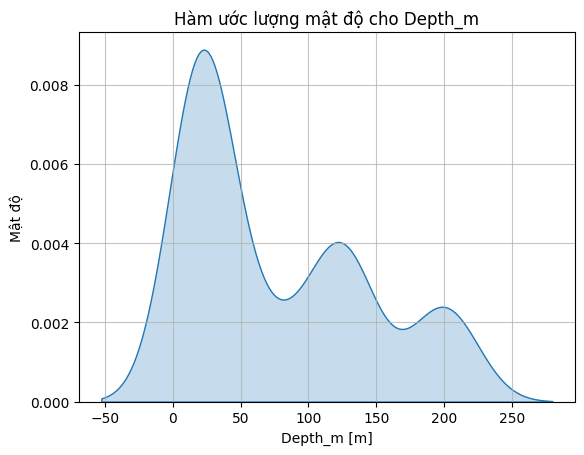

In [57]:
sns.kdeplot(data['Depth_m'], fill=True)
plt.title('Hàm ước lượng mật độ cho Depth_m')
plt.xlabel('Depth_m [m]')
plt.ylabel('Mật độ')
plt.grid(alpha=0.75)
plt.show()

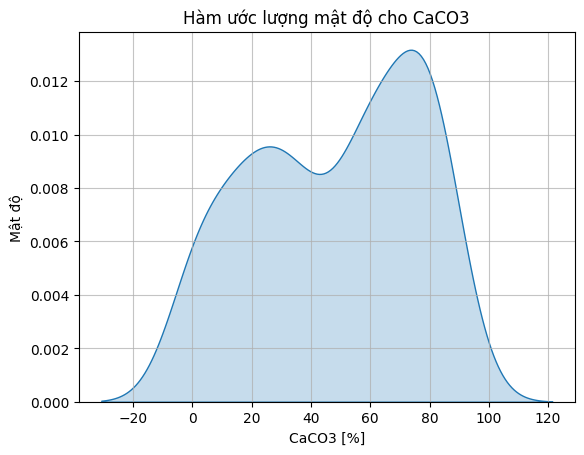

In [58]:
sns.kdeplot(data['CaCO3'], fill=True)
plt.title('Hàm ước lượng mật độ cho CaCO3')
plt.xlabel('CaCO3 [%]')
plt.ylabel('Mật độ')
plt.grid(alpha=0.75)
plt.show()

Nhận xét và Đề xuất hiệu chỉnh:
1. Biến Depth_m
- Nhận xét: Biểu đồ này cho thấy một phân bố đa đỉnh phức tạp, cụ thể là có 3 đỉnh và bị lệch trái. Đỉnh cao nhất (nơi có mật độ mẫu lớn nhất) nằm ở độ sâu nông, xấp xỉ 25m. Có hai đỉnh phụ khác ở độ sâu lớn hơn, một đỉnh rõ rệt ở khoảng 120m và một đỉnh nhỏ hơn ở khoảng 200m. Các "thung lũng" (vùng mật độ thấp) nằm ở khoảng 80m và 170m, cho thấy có sự gián đoạn trong việc lấy mẫu hoặc sự thay đổi trong các lớp địa tầng.
- Vấn đề: Phép ước lượng này có một vấn đề ở biên bên trái. Vì độ sâu là một đại lượng vật lý không thể âm, việc phần đuôi của biểu đồ tràn sang vùng giá trị < 0 là không hợp lý về mặt thống kê.
- Đề xuất: Để xử lý vấn đề dữ liệu chỉ nhận giá trị dương và hiện tượng tràn ở mốc 0, phép biến đổi logarit là một lựa chọn phù hợp.

2. Biến CaCO3
- Nhận xét: Biểu đồ này có phân bố 2 đỉnh rõ rệt, cho thấy dữ liệu được phân chia thành hai nhóm riêng biệt. Một đỉnh thấp hơn nằm ở vùng có nồng độ CaCO3 trung bình, khoảng 25%. Đỉnh cao nhất (nhóm mẫu chiếm đa số) nằm ở vùng nồng độ cao, xấp xỉ 75%.
- Vấn đề: Vấn đề chính nằm ở biên bên phải. CaCO3 là tỉ lệ phần trăm, về mặt vật lý phải bị chặn trong khoảng [0, 100]. Tuy nhiên, biểu đồ KDE tiêu chuẩn đã tràn ra ngoài, ước lượng mật độ cho các giá trị lớn hơn 100%. Điều này là vô lý.
- Đề xuất: Bắt buộc phải dùng phép biến đổi cho dữ liệu bị chặn. Phương pháp chính xác là biến đổi logit. Phép biến đổi này được thiết kế đặc biệt để xử lý dữ liệu tỉ lệ (bị chặn giữa 0 và 1), đảm bảo mật độ ước lượng nằm trọn trong phạm vi hợp lệ.